In [2]:
import win32wnet
from os.path import join
from getpass import getpass

import ezomero as ez
from omero.sys import Parameters
from omero.rtypes import rstring, rlong
from omero.gateway import BlitzGateway

from typing import Optional

# Linux commands on the server:
List mounted cifs volumes : `mount -v | grep 'type cifs'`

-> Shell script to get the mapping (for the server admin):
``` bash
#!/bin/bash

share_l=$(mount -v | grep 'type cifs')
while IFS= read -r line; do
    line=($line)
    echo "'"${line[0]}"':'"${line[2]}"'"
done <<< $share_l
```

# Utility to read client path and transform it to a local path (Windows)

In [2]:
local_drive = "Z:"  # The fileserver mounted volume
local_share = win32wnet.WNetGetUniversalName(local_drive, 1) # 1 is the infoLevel
local_share = local_share.replace("\\", "/")
local_mapping = {local_share: local_drive}

# Obtained from server admin (e.g. with the "Linux commands on the server")
# The mapping of a fileserver IP/name to the mounted path on the OMERO.server VM.
server_mapping = {"//fileserver-address/fs-name": "/mnt/inplace_import/fs-name"}


def get_image_clientpath(conn: BlitzGateway, 
                         image_id: int,
                         inplace_import_only: Optional[bool] = True):
    """Get the client_path (import source path) of an omero image.

    Parameters
    ----------
    conn : ``omero.gateway.BlitzGateway`` object
        OMERO connection.
     image_id : int
        Id of the image to get the client_path for.
    inplace_import_only : bool, optional
        Defines behavior for image not imported with 
        inplace-imports - set to``False`` to disable it.

    Returns
    -------
    client_path : Import source path of the image.
        Images imported with inplace-import will give the path
        of the fileshare mounted on the server. Convert it
        with you local fileshare mountpoint to get the path
        of the file.
        
    serie : The serie index of the image
        For the given client_path file, the image correspond to a
        certain serie index in the file.

    Notes
    -----
    User and group information comes from the `conn` object. Be sure to use
    ``ezomero.set_group`` to specify group prior to passing
    the `conn` object to this function.

    The returned path does not guarantee that the file exists or is the file
    expected by the user. Permissions of files imported to OMERO with in-place 
    import should be changed to read-only to prevent such issues.

    Examples
    --------
    # Return client_path of the image with ID 123:

    >>> img_fpath, serie_index = get_image_ids(conn, image_id=123)
    """
       
    img_obj, _  = ez.get_image(conn, image_id, no_pixels=True)
    if inplace_import_only:
        import_method = img_obj.getInplaceImport()
        if import_method not in ["ome.formats.importer.transfers.HardlinkFileTransfer",
                                 "ome.formats.importer.transfers.SymlinkFileTransfer"]:
            raise ValueError('The image is not "in-place" imported')

    q = conn.getQueryService()
    params = Parameters()

    params = Parameters()
    params.map = {"imageid": rlong(img_obj.getId())}
    results = q.projection(
        "select fe.clientPath, i.series "
        "from Image i "
        "join i.fileset.usedFiles fe "
        "where i.id = :imageid and index(fe) = 0",
        params,
        conn.SERVICE_OPTS
        )[0]

    return results[0].val, results[1].val


def map_to_local_path(server_mapping, local_mapping, path):
    res = ""
    for share_url, share_mount in server_mapping.items():
        if share_mount[0] == "/":
            share_mount = share_mount[1:]
        if path.find(share_mount) == 0:
            res = join(local_mapping[share_url], path[len(share_mount):])
            break
    return res


In [ ]:
GROUP = "your-group"
USER = "your-user"
PWD = getpass()
HOST = "your-server-adress"
PORT = 4064

# Test the connection
with ez.connect(USER, PWD, GROUP, HOST, PORT, secure=True) as conn:
    print(f"Connected: {conn.isConnected()}")

In [ ]:
IMG_ID = 514414
with ez.connect(USER, PWD, GROUP, HOST, PORT, secure=True) as conn:
    clientpath, serie = get_image_clientpath(conn, IMG_ID)
    mapped_path = map_to_local_path(server_mapping, local_mapping, clientpath)
    print(mapped_path,f"\nSerie: {serie}")

# Example to open image with bioformats

In [10]:
import matplotlib.pyplot as plt
import javabridge as jb  # REQUIRES https://pypi.org/project/python-bioformats/ and JDK installed
import bioformats as bf  # REQUIRES https://pypi.org/project/python-bioformats/ and JDK installed

jb.start_vm(class_path=bf.JARS)
# Don't forget to kill the VM at the end: jb.kill_vm()


def _init_logger():
    """
    This is so that Javabridge doesn't spill out a lot of DEBUG messages
    during runtime.
    From CellProfiler/python-bioformats.
    """
    rootLoggerName = jb.get_static_field("org/slf4j/Logger",
                                         "ROOT_LOGGER_NAME",
                                         "Ljava/lang/String;")

    rootLogger = jb.static_call("org/slf4j/LoggerFactory",
                                "getLogger",
                                "(Ljava/lang/String;)Lorg/slf4j/Logger;",
                                rootLoggerName)

    logLevel = jb.get_static_field("ch/qos/logback/classic/Level",
                                   "ERROR",
                                   "Lch/qos/logback/classic/Level;")

    jb.call(rootLogger,
            "setLevel",
            "(Lch/qos/logback/classic/Level;)V",
            logLevel)
_init_logger()

In [ ]:
reader = bf.ImageReader(mapped_path) # Initialize the reader and read individual planes (see bellow)

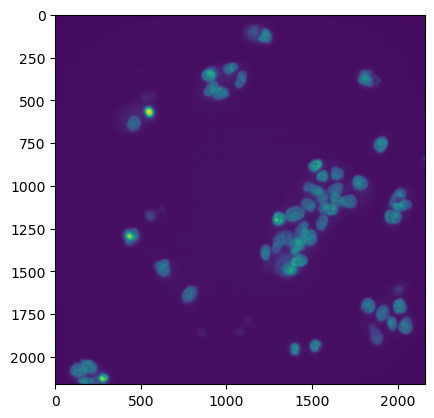

In [41]:
# if `czt` isn't working to select channel, try with `index`
img = reader.read(c=None, z=0, t=0, series=serie, index=4, rescale=False)
plt.figure()
plt.imshow(img)

### Example with large czi

In [ ]:
IMG_ID = 514414
conn.setGroupForSession(1756)
clientpath, serie = get_image_clientpath(conn, IMG_ID)
mapped_path = map_to_local_path(server_mapping, local_mapping, clientpath)
print(mapped_path,f"\nSerie: {serie}")

reader = bf.ImageReader(mapped_path) # Better to initialize reader and then read plane yourself

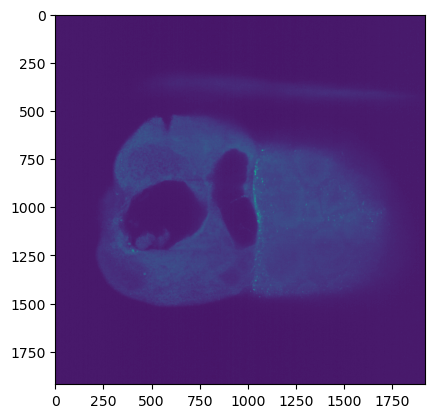

In [63]:
# if `czt` isn't working to select channel, try with `index`
img = reader.read(c=0, z=0, t=0, series=serie, index=150*4+0, rescale=False)
plt.figure()
plt.imshow(img)

In [64]:
jb.kill_vm()